### Title : Implement a Linear Regression Model to predict house prices for regions in the USA using the provided dataset.


#### 1) Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
np.random.seed(42)

#### 2) Load the Dataset

In [2]:
df = pd.read_csv('USA_Housing.csv')

In [3]:
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (5000, 7)


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


#### 3) Data Understanding and Pre-processing

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [5]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [6]:
# Check missing values
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [7]:
# Drop non-numeric identifier column (Address) before modeling
df_model = df.drop('Address', axis=1)
df_model.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


#### 4) Exploratory Data Analysis (EDA)

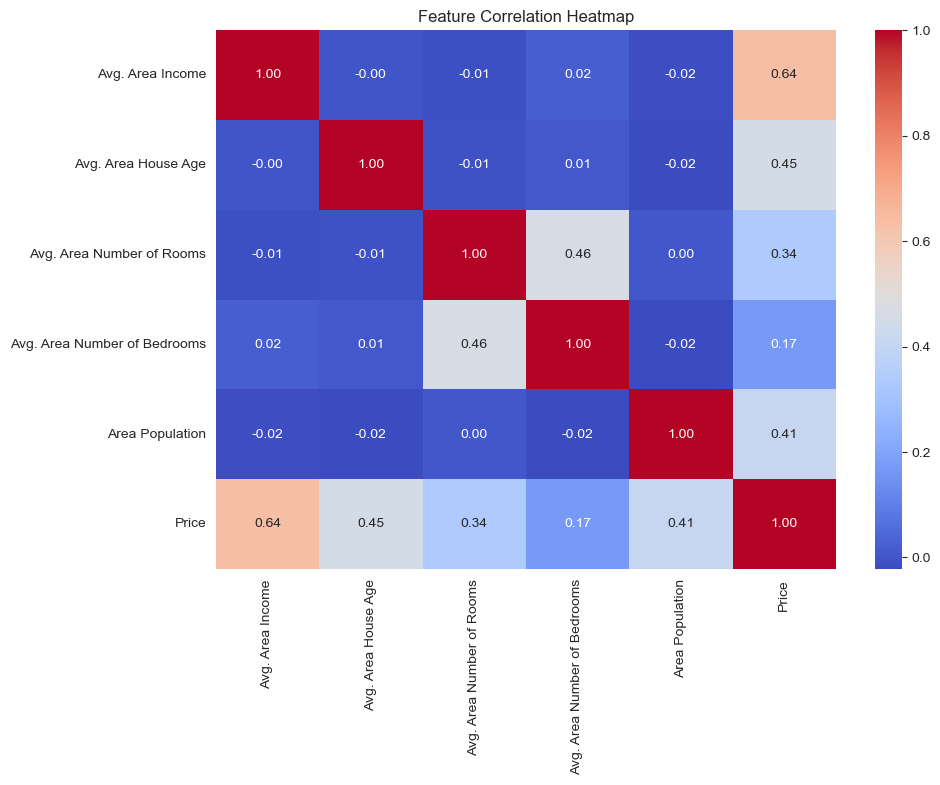

In [8]:
plt.figure(figsize=(10, 7))
corr = df_model.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

#### 5) Define Features and Target

In [9]:
X = df_model.drop('Price', axis=1)
y = df_model['Price']

print('Feature matrix shape:', X.shape)
print('Target vector shape :', y.shape)
X.head()

Feature matrix shape: (5000, 5)
Target vector shape : (5000,)


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,79545.458574,5.682861,7.009188,4.09,23086.800503
1,79248.642455,6.002900,6.730821,3.09,40173.072174
2,61287.067179,5.865890,8.512727,5.13,36882.159400
3,63345.240046,7.188236,5.586729,3.26,34310.242831
4,59982.197226,5.040555,7.839388,4.23,26354.109472


#### 6) Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (4000, 5)
X_test : (1000, 5)
y_train: (4000,)
y_test : (1000,)


#### 7) Train Linear Regression Model

In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print('Model training completed.')

Model training completed.


#### 8) Model Coefficients and Intercept

In [12]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})

print('Intercept:', lr_model.intercept_)
coeff_df

Intercept: -2635072.9009313583


,Feature,Coefficient
0,Avg. Area Income,21.652206
1,Avg. Area House Age,164666.480722
2,Avg. Area Number of Rooms,119624.012232
3,Avg. Area Number of Bedrooms,2440.377611
4,Area Population,15.270313


#### 9) Predictions and Evaluation

In [13]:
y_pred = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MAE  : {mae:,.2f}')
print(f'MSE  : {mse:,.2f}')
print(f'RMSE : {rmse:,.2f}')
print(f'R2   : {r2:.4f}')

MAE  : 80,879.10
MSE  : 10,089,009,300.89
RMSE : 100,444.06
R2   : 0.9180


In [14]:
results_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})
results_df.head(10)

,Actual Price,Predicted Price
1501,1.339096e+06,1.308588e+06
2586,1.251794e+06,1.237037e+06
2653,1.340095e+06,1.243429e+06
1055,1.431508e+06,1.228900e+06
705,1.042374e+06,1.063321e+06
106,1.555321e+06,1.544058e+06
589,1.250882e+06,1.094775e+06
2468,1.039381e+06,8.332847e+05
2413,8.324752e+05,7.884129e+05
1600,1.420648e+06,1.469715e+06


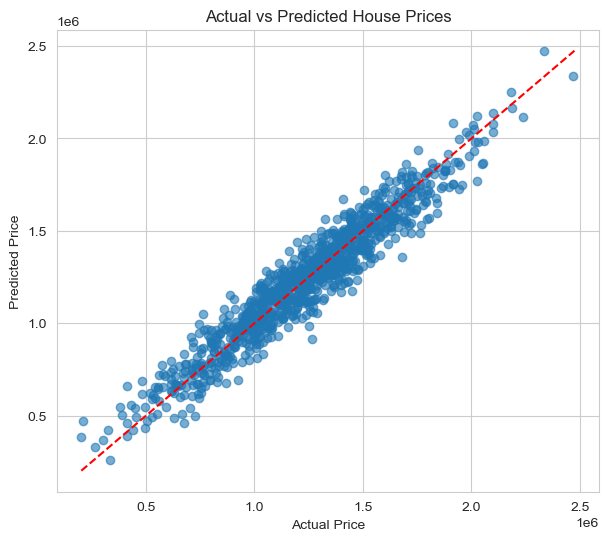

In [15]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')

# Ideal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.show()

In [16]:
# ---- User Input Prediction ----

print("Enter details to predict house price:")
avg_area_income = float(input("Average Area Income: "))
avg_area_house_age = float(input("Average Area House Age: "))
avg_area_rooms = float(input("Average Area Number of Rooms: "))
avg_area_bedrooms = float(input("Average Area Number of Bedrooms: "))
area_population = float(input("Area Population: "))

# Create DataFrame with SAME column names as training data
user_input_df = pd.DataFrame([{
    'Avg. Area Income': avg_area_income,
    'Avg. Area House Age': avg_area_house_age,
    'Avg. Area Number of Rooms': avg_area_rooms,
    'Avg. Area Number of Bedrooms': avg_area_bedrooms,
    'Area Population': area_population
}])

# Predict
predicted_price = lr_model.predict(user_input_df)

print(f"\n🏠 Predicted House Price: ${predicted_price[0]:,.2f}")

Enter details to predict house price:


Average Area Income:  79545.45
Average Area House Age:  5.68
Average Area Number of Rooms:  7
Average Area Number of Bedrooms:  4.09
Area Population:  23086.80



🏠 Predicted House Price: $1,222,459.06


“MAE shows the average absolute difference between actual and predicted values. In this model, the average error is around $80,000, which is reasonable for house price prediction.”

“RMSE is the square root of MSE and is in the same unit as the target variable, making it easier to interpret. Here, the model has an average error of about $100,000.”

“An R² score of 0.918 indicates that 91.8% of the variance in house prices is explained by the independent variables, which shows that the model has a strong predictive capability.”

The predicted value differs from the actual value because Linear Regression minimizes overall error across the dataset using MSE. It does not guarantee exact predictions for individual data points. Additionally, slight rounding differences in input values can lead to noticeable variation in output.
to prove this satement use below code:

 Use EXACT original values
test_exact = pd.DataFrame([{
    'Avg. Area Income': 79545.458574,
    'Avg. Area House Age': 5.682861,
    'Avg. Area Number of Rooms': 7.009188,
    'Avg. Area Number of Bedrooms': 4.09,
    'Area Population': 23086.800503
}])

print(model.predict(test_exact))

